# Segway model considering close loop latency of motor

Consider the fact that the motor will reach the target torque the second a new command is sent, we take into consideration the latency of the motor by adding the model for the current loop inside the model.

With:

$I_{target} = M_{target} / K_t$

Given that the voltage output of the current loop is:
$V_{out} = L \frac{dI}{dt} + E$

We can model the current loop as a first order system with a time constant $\tau = \frac{L}{R}$, where $R$ is the resistance of the motor. The transfer function of the current loop can be expressed as:
$$H(s) = \frac{1}{\tau s + 1}$$

As current is always proportional to torque, we can express the torque output of the motor as:$$M(s) = K_t I(s) = K_t H(s) I_{target}(s) = \frac{K_t}{\tau s + 1} I_{target}(s) = \frac{K_t}{\tau s + 1} \frac{M_{target}(s)}{K_t} = \frac{M_{target}(s)}{\tau s + 1}$$

In derivative form, this can be expressed as:$$\tau \frac{dM}{dt} + M = M_{target}$$, $$\frac{dM}{dt} = \frac{1}{\tau} (M_{target} - M)$$

# Simulation

- Velocity model:

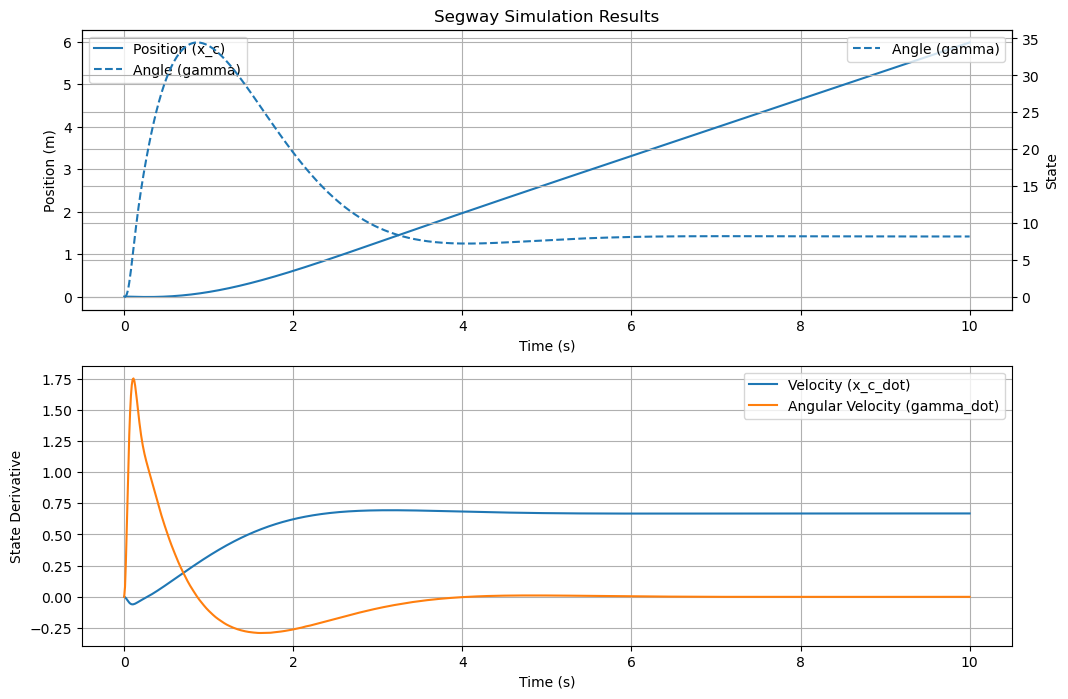

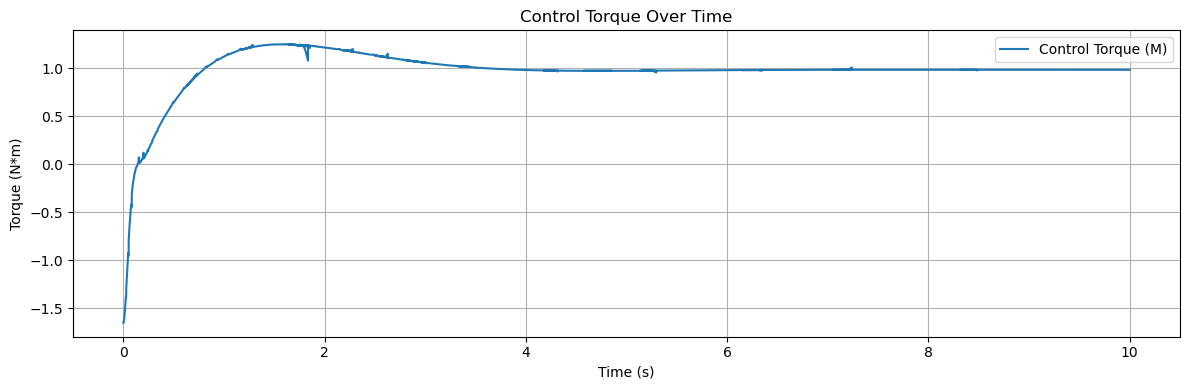

In [ ]:
from Runner import run_simulation
from Parameters import params
from Config import CONTROL_MODE, MODEL_T


params.tau_motor = 0.1

run_simulation(
    initial_state=[0.0, 0.0, 0.0, 0.0, 0.0], # for [x, x_dot, gamma, gamma_dot, Motor actual]
    time_span=(0, 10),
    control_mode=CONTROL_MODE.VELOCITY,
    desired_gamma=0.0,
    desired_velocity=0.5,
    model_type=MODEL_T.ROLLING_RESISTANCE_LATENCY,
    record_Torque=True,
    export_CSV_flag=True
)